# Autonomous Teleoperation

This notebook uses the trained model to control the Jetbot autonomously. It leverages the model outputs to compute speed and steering, limiting rapid changes to prevent sudden jerks.
It has been optimized with `torch.no_grad()` and FP16 (`half()`) precision to run at high frequency (aiming near 60 fps).

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import PIL.Image
import numpy as np
import time

import traitlets
import ipywidgets as widgets
from IPython.display import display

# JetBot hardware bindings (camera/motors)
from jetbot import Robot, Camera, bgr8_to_jpeg

ModuleNotFoundError: No module named 'jetbot'

### Optimize Model with TensorRT (Optional)
Executing the code below will use `torch2trt` to create an optimized TensorRT engine. This process takes a few minutes but is required to reach high FPS (up to 60 FPS) on the Jetson Nano. 
Note: You only need to run this once or whenever you have a new trained model.

In [ ]:
# use to install torch2trt: 
!git clone https://github.com/NVIDIA-AI-IOT/torch2trt
!cd torch2trt
!python setup.py install

In [4]:
import os
# Convert to TensorRT only when torch2trt is available and a CUDA device exists
has_torch2trt = False
try:
    from torch2trt import torch2trt
    has_torch2trt = True
except Exception:
    pass

trt_model_path = '../models/best_steering_model_xy_trt.pth'
if has_torch2trt and torch.cuda.is_available():
    # 1. Create a dummy input (matching our 224x224 input size)
    data = torch.zeros((1, 3, 224, 224)).cuda().half()
    print("Starting TensorRT conversion... (this may take 2-5 minutes)")
    model_trt = torch2trt(model, [data], fp16_mode=True)
    torch.save(model_trt.state_dict(), trt_model_path)
    print(f"TensorRT model saved to {trt_model_path}")
    model = model_trt
else:
    print("torch2trt not available or CUDA not present; skipping conversion.")

torch2trt not available or CUDA not present; skipping conversion.


### Load the Model
We load our ResNet18 model and set it up for evaluation mode.
Note: For native PyTorch, it's very difficult to reach 60 FPS. Jetson Nano struggles with the framework overhead (usually yielding ~20-30 FPS for ResNet18).
For 60 FPS, the PyTorch model should ideally be compiled into a TensorRT optimized engine using `torch2trt`. 
If you have a TensorRT model (`best_steering_model_xy_trt.pth`), you should load that using `TRTModule()`. 
For now, we'll try to get the fastest native PyTorch performance using `half()` precision.

In [5]:
import os
# Guard TRT import - may not be available on non-Jetson/dev machines
try:
    from torch2trt import TRTModule
    has_trtmodule = True
except Exception:
    TRTModule = None
    has_trtmodule = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)

# Best model path
model_path = '../models/best_steering_model_xy.pth'
trt_model_path = '../models/best_steering_model_xy_trt.pth'

# Load a TRT engine if present and supported, otherwise load PyTorch weights
if os.path.exists(trt_model_path) and has_trtmodule and device.type == 'cuda':
    print("Loading optimized TensorRT model...")
    model = TRTModule()
    model.load_state_dict(torch.load(trt_model_path))
else:
    print("Loading standard PyTorch model (native)...")
    model.load_state_dict(torch.load(model_path))
    model = model.to(device).eval()
    if device.type == 'cuda':
        model = model.half()

Loading standard PyTorch model (native)...


c:\Users\Komputer\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Komputer\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [8]:
# Compatibility check: CUDA, PyTorch, and torch2trt
import torch
print('torch version:', getattr(torch, '__version__', None))
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.version.cuda:', getattr(torch.version, 'cuda', None))

try:
    import torch2trt
    print('torch2trt import: OK')
except Exception as e:
    print('torch2trt import failed:', e)
    print('NOTE: torch2trt requires PyTorch built with CUDA and a system TensorRT installation.'
          )
    if not torch.cuda.is_available():
        print('CUDA not available: install a CUDA-enabled PyTorch build matching your CUDA driver.')
    print("Suggested (example) commands (adjust CUDA version & platform):")
    print('pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision torchaudio')
    print('git clone https://github.com/NVIDIA-AI-IOT/torch2trt && cd torch2trt && python setup.py install')

torch version: 2.7.1+cpu
torch.cuda.is_available(): False
torch.version.cuda: None
torch2trt import failed: No module named 'torch2trt'
NOTE: torch2trt requires PyTorch built with CUDA and a system TensorRT installation.
CUDA not available: install a CUDA-enabled PyTorch build matching your CUDA driver.
Suggested (example) commands (adjust CUDA version & platform):
pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision torchaudio
git clone https://github.com/NVIDIA-AI-IOT/torch2trt && cd torch2trt && python setup.py install


### High-Frequency Preprocessing
We pre-load mean/std constants directly to GPU to avoid CPU-GPU syncs on every frame.

In [9]:
# Prepare mean/std on the correct device and dtype
mean = torch.Tensor([0.485, 0.456, 0.406]).to(device)
std = torch.Tensor([0.229, 0.224, 0.225]).to(device)

def preprocess(image):
    image = PIL.Image.fromarray(image)
    image = transforms.functional.resize(image, (224, 224))
    t = transforms.functional.to_tensor(image).to(device)
    if device.type == 'cuda':
        t = t.half()
        mean_t = mean.half()
        std_t = std.half()
    else:
        mean_t = mean
        std_t = std
    t.sub_(mean_t[:, None, None]).div_(std_t[:, None, None])
    return t[None, ...]

### Initialize Camera and Robot
Prepare the camera output and basic widgets so we can monitor what Jetbot sees.

In [ ]:
camera = Camera.instance()
robot = Robot()

image_widget = widgets.Image()
traitlets.dlink((camera, 'value'), (image_widget, 'value'), transform=bgr8_to_jpeg)

display(image_widget)

### UI Controls for Driving and Output Filters
Adjust `max_speed_delta` and `max_steering_delta` to limit how fast speed and direction can change.
This smoothing disallows sharp changes across individual frames.

In [93]:
# Speed gain controls the nominal forward speed of the robot.
speed_gain_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.3, description='speed gain')
# Steering gain scales the proportional steering response from the network angle.
steering_gain_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.4, description='steering gain')
# Steering KD adds a derivative term to damp quick angle changes.
steering_dgain_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.001, value=0.0, description='steering kd')
# Steering bias shifts the steering command left/right to compensate for hardware drift.
steering_bias_slider = widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=0.0, description='steering bias')

# Delta clippers limit how quickly speed and steering can change from frame to frame.
max_speed_delta = widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description='max speed delta')
max_steer_delta = widgets.FloatSlider(min=0.01, max=0.5, step=0.01, value=0.10, description='max steering delta')

# Target FPS caps how often the inference callback updates the motors.
target_fps_slider = widgets.IntSlider(min=1, max=60, step=1, value=15, description='target FPS')

controls_box = widgets.VBox([
    speed_gain_slider, 
    steering_gain_slider, 
    steering_dgain_slider, 
    steering_bias_slider,
    max_speed_delta,
    max_steer_delta,
    target_fps_slider
])
display(controls_box)

# Diagnostic slider for the model's x output in normalized coordinates.
x_slider = widgets.FloatSlider(min=-1.0, max=1.0, description='network x')
# Diagnostic slider for the model's y output in normalized coordinates.
y_slider = widgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='network y')
# Diagnostic slider showing the final steering command sent to the motors.
steering_slider = widgets.FloatSlider(min=-1.0, max=1.0, description='actual steer')
# Diagnostic slider showing the final speed command sent to the motors.
speed_slider = widgets.FloatSlider(min=0, max=1.0, orientation='vertical', description='actual speed')

display(widgets.HBox([y_slider, speed_slider]))
display(x_slider, steering_slider)

# Emergency stop button for inference control.
stop_inference_button = widgets.Button(description='⛔ Stop inference', button_style='danger')
display(stop_inference_button)

FloatSlider(value=0.0, description='network x', max=1.0, min=-1.0)

FloatSlider(value=0.0, description='actual steer', max=1.0, min=-1.0)

Button(button_style='danger', description='⛔ Stop inference', style=ButtonStyle())

### Inference Cycle
Listens to camera feed changes and directly evaluates to motor control.

In [94]:
angle = 0.0
angle_last = 0.0

current_speed = 0.0
current_steering = 0.0
last_inference_time = 0.0


def clamp_delta(new_val, old_val, max_delta):
    """Restricts how rapidly a value can change compared to the previous frame."""
    if new_val - old_val > max_delta:
        return old_val + max_delta
    elif old_val - new_val > max_delta:
        return old_val - max_delta
    return new_val


def execute(change):
    global angle, angle_last
    global current_speed, current_steering, last_inference_time
    
    current_time = time.time()
    # Enforce FPS limit
    if current_time - last_inference_time < 1.0 / target_fps_slider.value:
        return
    last_inference_time = current_time
    
    image = change['new']
    
    # Inference mode skips gradient tracking for higher FPS
    with torch.no_grad():
        out = model(preprocess(image))
        # Ensure output is on CPU as float32 for numpy operations
        xy = out.detach().float().cpu().numpy().flatten()
        
    # Interpret network output as a normalized target point in image coordinates.
    # x > 0 means target point is to the right; y > 0 means target point is lower in the frame.
    x = float(xy[0])
    y = float(xy[1])
    # Defensive: avoid very small forward component causing unstable angles.
    y = max(y, 1e-3)

    x_slider.value = x
    y_slider.value = y
    
    # Steering angle is measured from the forward axis to the target point.
    angle = np.arctan2(x, y)
    pid = angle * steering_gain_slider.value + (angle - angle_last) * steering_dgain_slider.value
    angle_last = angle
    
    target_steering = pid + steering_bias_slider.value
    # Speed remains positive by default; steering is handled through differential wheel mixing.
    target_speed = speed_gain_slider.value
    
    # --- Constraints: Clip change rate per frame ---
    max_sd = max_speed_delta.value
    max_td = max_steer_delta.value
    
    current_speed = clamp_delta(target_speed, current_speed, max_sd)
    current_steering = clamp_delta(target_steering, current_steering, max_td)
    
    # Drive the widgets to visualize output signal
    steering_slider.value = current_steering
    speed_slider.value = current_speed
    
    # Differential-drive mixing: positive steering should increase left wheel and decrease right wheel.
    left_power = current_speed + current_steering
    right_power = current_speed - current_steering
    left_power = max(-1.0, min(1.0, left_power))
    right_power = max(-1.0, min(1.0, right_power))
    
    robot.left_motor.value = left_power
    robot.right_motor.value = right_power


def start_inference(_=None):
    try:
        camera.unobserve(execute, names='value')
    except Exception:
        pass
    camera.observe(execute, names='value')
    print('Inference camera subscription is active.')


def stop_inference(_=None):
    global current_speed, current_steering
    try:
        camera.unobserve(execute, names='value')
    except Exception:
        pass
    robot.stop()
    current_speed = 0.0
    current_steering = 0.0
    speed_slider.value = 0.0
    steering_slider.value = 0.0
    print('Inference stopped and robot halted.')


stop_inference_button.on_click(stop_inference)

### **Start driving!**
Executes whenever the camera captures a fresh frame.

In [ ]:
start_inference()

### Stop
Detach observation and pause robot.

In [ ]:
stop_inference()

Testing inference on: 1778601215.983851.png


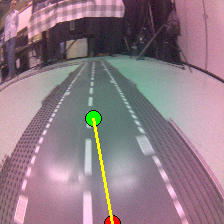


INFERENCE RESULTS
Network output (x, y): (-0.1661, 0.0565)
Predicted angle (rad): -1.2430
Target speed: 0.1700
Target steering: -0.4972

MOTOR POWERS:
  Left motor:  -0.3272
  Right motor: +0.6672

MOVEMENT DIRECTION:
  Speed magnitude: 0.1700 (0=stopped, 1=max)
  Turn angle: -71.22° (neg=left, pos=right)


In [95]:
# Test inference on random image from dataset
import os
import glob
import random
from PIL import Image, ImageDraw
from IPython.display import display

# Find a random image from dataset
image_dir = '../../data/dataset_images'
image_files = glob.glob(os.path.join(image_dir, '*.jpg')) + glob.glob(os.path.join(image_dir, '*.jpeg')) + glob.glob(os.path.join(image_dir, '*.png'))


def pixel_from_norm(x_norm, y_norm, img_size):
    px = int(round(x_norm * img_size / 2 + img_size / 2))
    py = int(round(y_norm * img_size / 2 + img_size / 2))
    px = max(0, min(px, img_size - 1))
    py = max(0, min(py, img_size - 1))
    return px, py

if image_files:
    random_image_path = random.choice(image_files)
    print(f"Testing inference on: {os.path.basename(random_image_path)}")
    
    # Load image
    test_image_pil = PIL.Image.open(random_image_path).convert('RGB')
    
    # Convert to numpy array for preprocessing
    test_image_np = np.array(test_image_pil)
    
    # Run inference
    with torch.no_grad():
        out = model(preprocess(test_image_np))
        xy = out.detach().float().cpu().numpy().flatten()
    
    x_out = float(np.clip(xy[0], -1.0, 1.0))
    y_out = float(np.clip(xy[1], -1.0, 1.0))
    
    # Compute steering (same interpretation as training helper)
    angle_pred = np.arctan2(x_out, y_out)
    pid_steering = angle_pred * steering_gain_slider.value
    target_steering = pid_steering + steering_bias_slider.value
    target_speed = speed_gain_slider.value
    
    final_steering = np.clip(target_steering, -1.0, 1.0)
    final_speed = np.clip(target_speed, 0.0, 1.0)
    
    # Motor powers
    left_power_test = np.clip(final_speed + final_steering, -1.0, 1.0)
    right_power_test = np.clip(final_speed - final_steering, -1.0, 1.0)
    
    # Draw the same type of annotation used in the training notebook helper:
    # one point for the prediction, one for the image center/bottom reference, and a line between them.
    img_size = 224
    annotated = test_image_pil.resize((img_size, img_size), Image.Resampling.BILINEAR).copy()
    draw = ImageDraw.Draw(annotated)
    pred_px, pred_py = pixel_from_norm(x_out, y_out, img_size)
    center_x, center_y = img_size // 2, img_size - 1
    
    draw.ellipse((pred_px - 8, pred_py - 8, pred_px + 8, pred_py + 8), fill=(0, 255, 0), outline=(0, 0, 0))
    draw.ellipse((center_x - 8, center_y - 8, center_x + 8, center_y + 8), fill=(255, 0, 0), outline=(0, 0, 0))
    draw.line((pred_px, pred_py, center_x, center_y), fill=(255, 255, 0), width=3)
    
    display(annotated)
    
    # Display info
    print("\n" + "="*50)
    print("INFERENCE RESULTS")
    print("="*50)
    print(f"Network output (x, y): ({x_out:.4f}, {y_out:.4f})")
    print(f"Predicted angle (rad): {angle_pred:.4f}")
    print(f"Target speed: {final_speed:.4f}")
    print(f"Target steering: {final_steering:.4f}")
    print(f"\nMOTOR POWERS:")
    print(f"  Left motor:  {left_power_test:+.4f}")
    print(f"  Right motor: {right_power_test:+.4f}")
    print(f"\nMOVEMENT DIRECTION:")
    print(f"  Speed magnitude: {final_speed:.4f} (0=stopped, 1=max)")
    print(f"  Turn angle: {np.degrees(angle_pred):.2f}° (neg=left, pos=right)")
    print("="*50)
else:
    print(f"No images found in {image_dir}")